In [1]:
from datetime import datetime

import pandas as pd

from energymanagementrl.pv_prod_simulation.main import run_energy_production_prediction, analyze_production, WeatherType
from energymanagementrl.pv_prod_simulation.simulation import PanelModel, ArrayConfig, PlantConfig

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [3]:
start = datetime.strptime('2021-04-10', '%Y-%m-%d')
end = datetime.strptime('2024-12-10', '%Y-%m-%d')

In [4]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=9, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=9, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)

Coordinates: 37.5625°N, 15.0°E
Elevation: 541.0 m asl
Timezone: b'Europe/Rome' b'CET'
Total AC energy: 131254.95 kWh
Max production: 5.76 kW at 2021-04-10 10:00:00
Production starts at: 2021-04-10 04:35:00, ends at: 2024-12-10 15:40:00


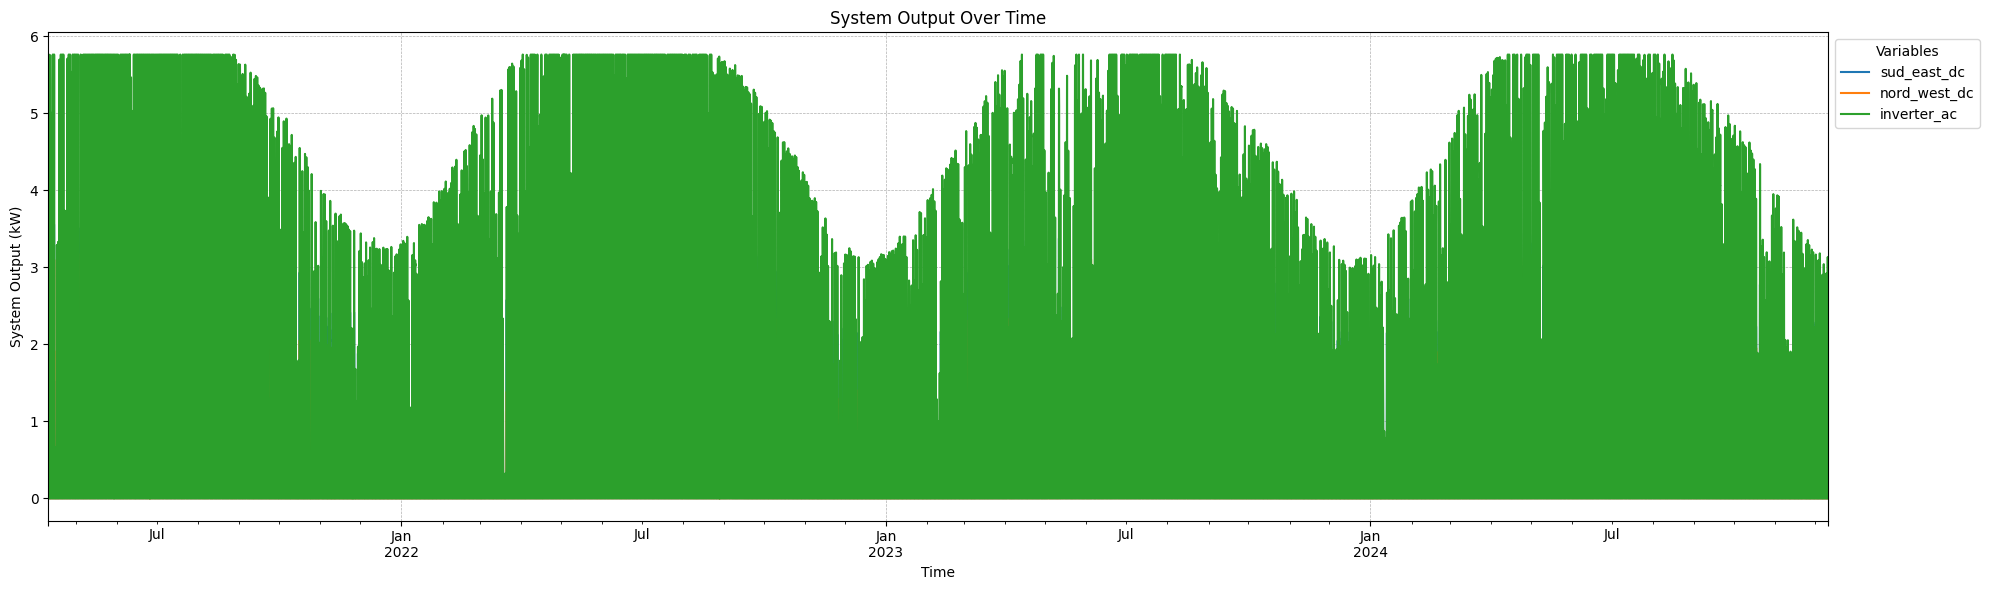

(np.float64(5.76),
 Timestamp('2021-04-10 10:00:00'),
 Timestamp('2021-04-10 04:35:00'),
 Timestamp('2024-12-10 15:40:00'))

In [5]:
open_meteo_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
    WeatherType.open_meteo
)
open_meteo_production_df = open_meteo_production_df.tz_convert('UTC').tz_localize(None)
open_meteo_production_df = open_meteo_production_df.resample('5min').interpolate(method='linear')
analyze_production(open_meteo_production_df)

Total AC energy: 142464.15 kWh
Max production: 5.76 kW at 2021-04-29 10:45:00
Production starts at: 2021-04-10 04:50:00, ends at: 2024-12-09 15:25:00


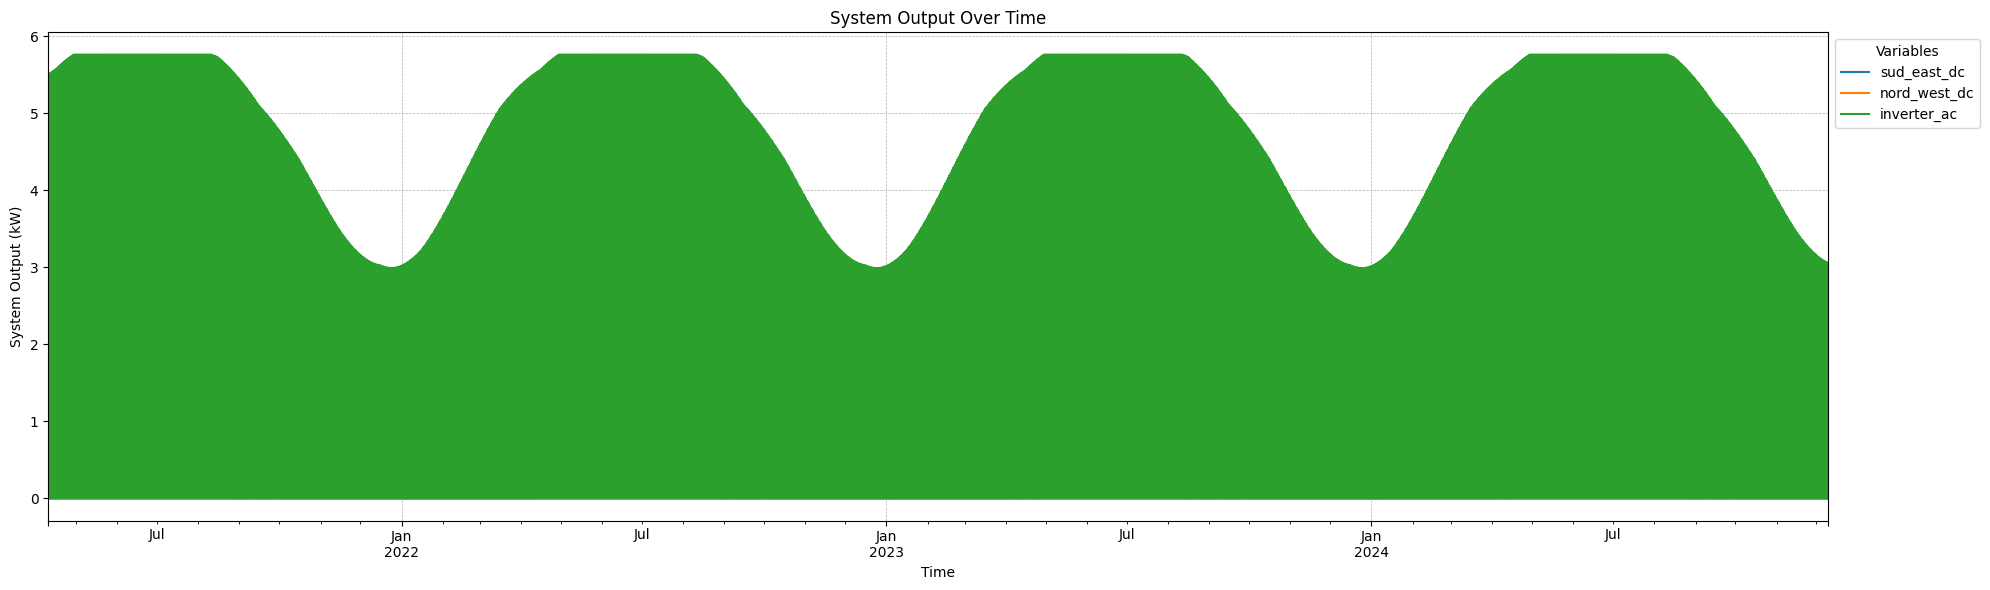

(np.float64(5.76),
 Timestamp('2021-04-29 10:45:00'),
 Timestamp('2021-04-10 04:50:00'),
 Timestamp('2024-12-09 15:25:00'))

In [6]:
clear_sky_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
)
clear_sky_production_df.index = clear_sky_production_df.index.tz_localize(None)
clear_sky_production_df = clear_sky_production_df.resample('5min').interpolate(method='linear')
analyze_production(clear_sky_production_df)

In [7]:
clear_sky_production_df.rename({'inverter_ac': 'production_optimal_kw'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'production_weather_dependent_kw'}, axis=1, inplace=True)

<Axes: >

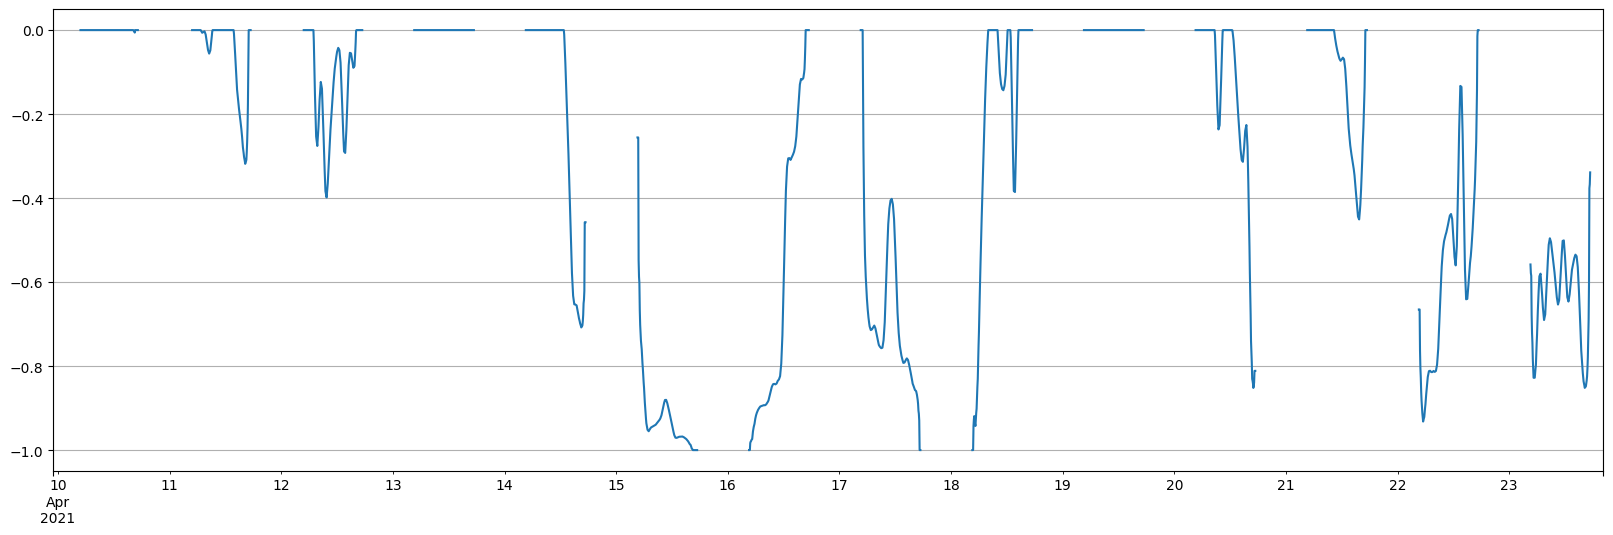

In [24]:
df = pd.concat([clear_sky_production_df.production_optimal_kw,
                open_meteo_production_df.production_weather_dependent_kw], axis=1)
df['residual'] = df.production_weather_dependent_kw - df.production_optimal_kw
df['residual_weather'] = df['residual'].clip(upper=0)
df['residual_weather_PCT'] = df['residual_weather']/ df.production_optimal_kw
df['residual_weather_PCT'][:4000].plot(figsize=(20, 6),grid=True)

In [ ]:
df['residual']

In [ ]:
df